In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

## 预测订单在未来被取消的概率

In [4]:
# 数据读取
dtype = {
    "InvoiceNo": "string",
    "StockCode": "string",
    "Description": "string",
    "Quantity": "int32",
    "InvoiceDate":"string",
    "UnitPrice": "float32",
    "CustomerID": "string",
    "Country": "string"
}
filename = "./Online Retail.xlsx"
sales_success = pd.read_excel(filename, sheet_name='Online Retail', dtype=dtype, engine='calamine')

In [6]:
sales_success.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [8]:
# 数据预处理
# 标记订单是否被取消
sales_success['IsCancelled'] = sales_success['InvoiceNo'].str.startswith('C')
# 去除客户ID缺失值
sales_success.dropna(subset=['CustomerID'], inplace=True)
# 转换日期类型
sales_success['InvoiceDate'] = pd.to_datetime(sales_success['InvoiceDate'])
# 计算 TotalPrice
sales_success['TotalPrice'] = sales_success['Quantity'] * sales_success['UnitPrice']

In [10]:
# 只用正金额、非C订单为样本
samples = sales_success[
    (~sales_success['InvoiceNo'].str.startswith('C')) &
    (sales_success['Quantity'] > 0) &
    (sales_success['TotalPrice'] > 0)
].copy()

数据集中每一个C开头的订单号都对应一个原订单，而非在退款时反写上游的订单号，因此要先去除使用的数据集中所有订单号为C开头的数据，随后根据这些数据确定和标记被取消（退款）的情况。

In [13]:
# 有效退款单
refunds = sales_success[
    (sales_success['InvoiceNo'].str.startswith('C')) &
    (sales_success['StockCode'] != 'D') &
    (sales_success['Quantity'] < 0)
]

由于打折（Discount）的订单号同样以C开头，因此还要确认有效的退款单，这一点可以通过数据中的StockCode字段确认。在确定有效的退款单和原订单后，开始打标签，这步在运行中耗时较长，逻辑是寻找C开头的订单号对应的订单发生时间前，顾客ID与商品描述一致，且购买数量大于退款数量的记录，这样的记录如果存在就将该数据标记为“被退款”。

In [16]:
# 商品级别打标签
def label_refunded(row, refunds_df):
    mask = (
        (refunds_df['CustomerID'] == row['CustomerID']) &
        (refunds_df['Description'] == row['Description']) &
        (refunds_df['InvoiceDate'] > row['InvoiceDate'])
    )
    refund_qty = -refunds_df[mask]['Quantity'].sum()
    return refund_qty > 0 and refund_qty <= row['Quantity']

samples['IsRefunded'] = samples.apply(lambda row: label_refunded(row, refunds), axis=1)

影响因素方面，考虑到订单退款率和顾客以及商品本身的关联较大，纳入考虑，此外，不同地区的购买文化、时间（晚上容易冲动消费）、购买数量（买多了）等因素也被纳入考虑，因此要对这几个特征进行处理。

In [18]:
# 按时间排序，确保历史计算基于过去,避免数据泄露
samples = samples.sort_values('InvoiceDate').reset_index(drop=True)
# 客户历史退款率（基于订单发生之前的历史数据）
samples['CustomerRefundRate'] = (
    samples.groupby('CustomerID')['IsRefunded']
    .transform(lambda x: x.shift().expanding().mean())
    .fillna(0)   # 第一个订单前无历史订单，填充0
)


In [19]:
# 时间特征
samples['Hour'] = samples['InvoiceDate'].dt.hour
samples['Weekday'] = samples['InvoiceDate'].dt.weekday


In [20]:
# 国家历史退货率（按时间顺序）
samples['CountryRefundRate'] = (
    samples.groupby('Country')['IsRefunded']
    .transform(lambda x: x.shift().expanding().mean())
    .fillna(0)
)

# 商品历史退货率
samples['DescriptionRefundRate'] = (
    samples.groupby('Description')['IsRefunded']
    .transform(lambda x: x.shift().expanding().mean())
    .fillna(0)
)


In [21]:
# 特征选择
features = [
    'TotalPrice',
    'Quantity',
    'CustomerRefundRate',
    'CountryRefundRate',        
    'DescriptionRefundRate',    
    'Hour',
    'Weekday'
]
X = samples[features]
y = samples['IsRefunded']

此处的数据分布检查，是由于一开始时打标签的逻辑有误，出现了数据集中y值全为False的情况，选择保留是作为调试语句进行参考；分层采样是为了避免在采样时出现某个集中完全不存在被退款订单的情况，也更符合长期运营的实际情况。

In [23]:
# 数据分布检查
print(y.value_counts())

# 分层采样
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


IsRefunded
False    386662
True      11222
Name: count, dtype: int64


可以看出该做法可行，随后进行训练与评估。

In [25]:
# 训练与评估
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)
print("AUC:", roc_auc_score(y_test, y_pred_prob))
print("混淆矩阵:\n", confusion_matrix(y_test, y_pred))
print("分类报告:\n", classification_report(y_test, y_pred))

AUC: 0.8582112468998516
混淆矩阵:
 [[77146   187]
 [ 2042   202]]
分类报告:
               precision    recall  f1-score   support

       False       0.97      1.00      0.99     77333
        True       0.52      0.09      0.15      2244

    accuracy                           0.97     79577
   macro avg       0.75      0.54      0.57     79577
weighted avg       0.96      0.97      0.96     79577



到这里可以看出，模型判断的总体准确率较高，也具有一定的识别退款订单的能力，但漏报的情况比较多（准确率0.52，尤其是召回率仅0.09）。考虑到该平台本身的退款比例就不算极高，我认为这一结果可以接受，如果平台认为退款的损失很大，不希望漏报，则可以通过降低模型的阈值（默认为0.5）来减少漏报的情况，但这一行为会导致整体准确率下降，并提高误报的数量，在下下个cell中可以看到结果。各影响因素的重要程度在下段代码中有可视化。

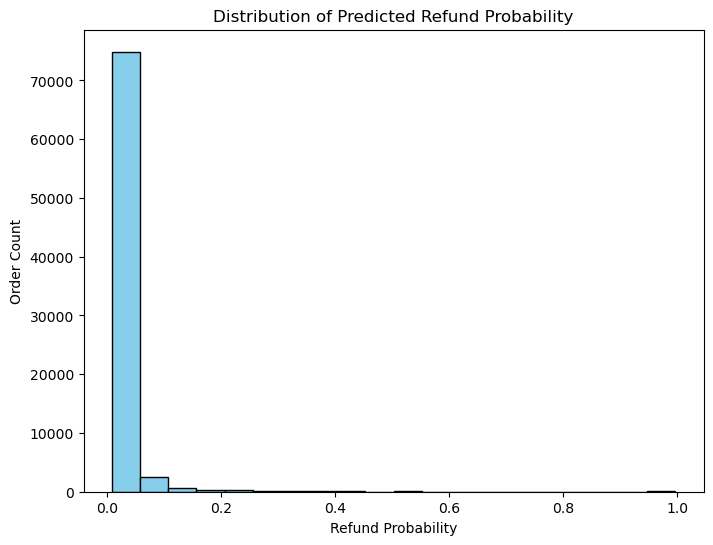

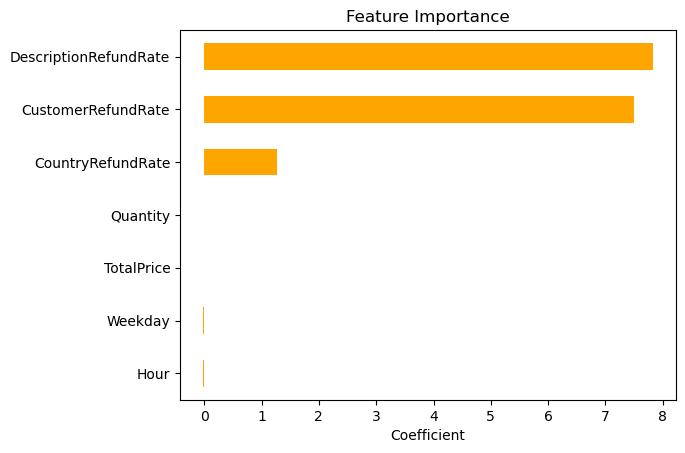

In [27]:
# 可视化部分
plt.figure(figsize=(8, 6))
plt.hist(y_pred_prob, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Refund Probability')
plt.ylabel('Order Count')
plt.title('Distribution of Predicted Refund Probability')
plt.show()

feature_importance = pd.Series(model.coef_[0], index=features)
feature_importance.sort_values().plot(kind='barh', color='orange', title='Feature Importance')
plt.xlabel('Coefficient')
plt.show()

In [28]:
# 调整阈值以提升对 True（被退货）的判断能力
threshold = 0.2
y_pred_thresh = (y_pred_prob > threshold).astype(int)

print(f"阈值: {threshold}")
print("混淆矩阵:\n", confusion_matrix(y_test, y_pred_thresh))
print("分类报告:\n", classification_report(y_test, y_pred_thresh))

阈值: 0.2
混淆矩阵:
 [[76600   733]
 [ 1848   396]]
分类报告:
               precision    recall  f1-score   support

       False       0.98      0.99      0.98     77333
        True       0.35      0.18      0.23      2244

    accuracy                           0.97     79577
   macro avg       0.66      0.58      0.61     79577
weighted avg       0.96      0.97      0.96     79577



将阈值降低至0.2后，预测正确的样本数从77348变为76996例，主要是False类的召回率降低，但相对的True类的召回率上升，总体准确率下降幅度不大，可以考虑实际业务情况灵活选择阈值。

## 预测90天内的销量

先使用单变量LSTM模型作为基线。

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim

In [33]:
# 数据准备
sales_success['InvoiceDate'] = pd.to_datetime(sales_success['InvoiceDate'])
sales_success['Date'] = sales_success['InvoiceDate'].dt.date
daily_sales = sales_success.groupby('Date')['Quantity'].sum().reset_index()

考虑到数据波动较大，我选择使用过去30天数据预测下一天的销售量。

In [35]:
# 销量归一化
from sklearn.preprocessing import StandardScaler
scaler_uni = StandardScaler()
sales = daily_sales['Quantity'].values.reshape(-1, 1)
sales_scaled = scaler_uni.fit_transform(sales).flatten()
window_size = 30  # 用前30天预测后一天
X, y = [], []
for i in range(len(sales_scaled) - window_size):
    X.append(sales_scaled[i:i+window_size])
    y.append(sales_scaled[i+window_size])
X = np.array(X)
y = np.array(y)

In [36]:
# PyTorch tensor
X_tensor = torch.FloatTensor(X).unsqueeze(-1)
y_tensor = torch.FloatTensor(y)

In [37]:
# 训练模型 
split = int(len(X_tensor)*0.8)
X_train = X_tensor[:split]
y_train = y_tensor[:split]
X_test = X_tensor[split:]
y_test = y_tensor[split:]

class SalesLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.squeeze(-1)

model = SalesLSTM()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 200
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

Epoch 0, Loss: 0.8524
Epoch 10, Loss: 0.6715
Epoch 20, Loss: 0.7043
Epoch 30, Loss: 0.6647
Epoch 40, Loss: 0.6461
Epoch 50, Loss: 0.5696
Epoch 60, Loss: 0.5101
Epoch 70, Loss: 0.4131
Epoch 80, Loss: 0.3103
Epoch 90, Loss: 0.2874
Epoch 100, Loss: 0.2034
Epoch 110, Loss: 0.2026
Epoch 120, Loss: 0.1175
Epoch 130, Loss: 0.0623
Epoch 140, Loss: 0.0364
Epoch 150, Loss: 0.0144
Epoch 160, Loss: 0.0056
Epoch 170, Loss: 0.0019
Epoch 180, Loss: 0.0008
Epoch 190, Loss: 0.0003


In [38]:
# 测试集评估
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test).numpy()
    y_true_scaled = y_test.numpy()

# 反归一化销量
y_pred = scaler_uni.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler_uni.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()

# 计算MAE和RMSE
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f'Test MAE: {mae:.2f}, RMSE: {rmse:.2f}')

Test MAE: 11514.49, RMSE: 15832.95


200epoch将误差降到较低水平，使用此模型递推此后90天的销售量预测。

In [40]:
# 预测未来90天（递推法）
model.eval()
with torch.no_grad():
    # 用历史最后window_size天作为初始输入
    last_window = sales_scaled[-window_size:]  # shape: [window_size]
    future_preds = []
    input_seq = last_window.copy()
    for i in range(90):
        input_tensor = torch.FloatTensor(input_seq).unsqueeze(0).unsqueeze(-1)  # [1, window_size, 1]
        next_pred_scaled = model(input_tensor).item()
        future_preds.append(next_pred_scaled)
        # 滚动窗口：去掉第一个，加上新预测
        input_seq = np.append(input_seq[1:], next_pred_scaled)

    # 反归一化
    future_preds_inv = scaler_uni.inverse_transform(np.array(future_preds).reshape(-1, 1)).flatten()


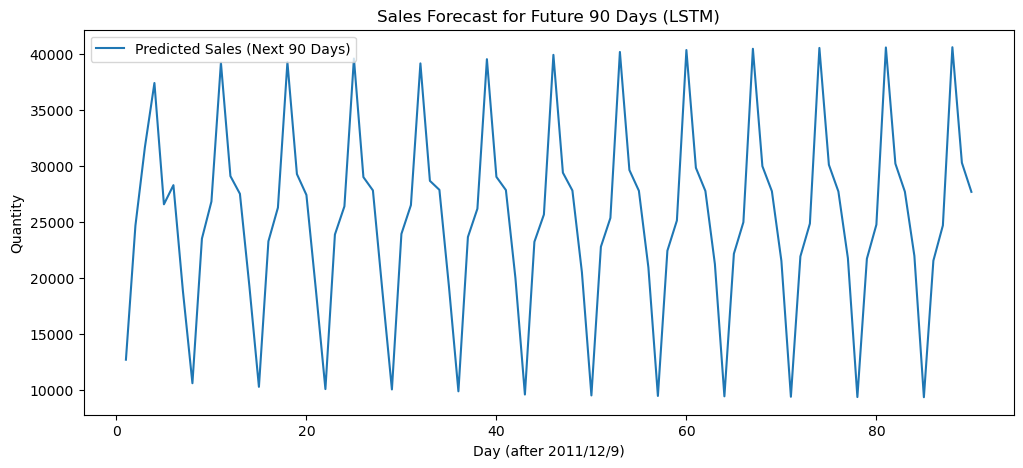

In [41]:
# 结果可视化
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(range(1, 91), future_preds_inv, label='Predicted Sales (Next 90 Days)')
plt.title("Sales Forecast for Future 90 Days (LSTM)")
plt.xlabel("Day (after 2011/12/9)")
plt.ylabel("Quantity")
plt.legend()
plt.show()


In [42]:
# 输出预测结果
future_dates = pd.date_range(start=daily_sales['Date'].iloc[-1] + pd.Timedelta(days=1), periods=90)
future_df = pd.DataFrame({'Date': future_dates, 'Predicted_Sales': future_preds_inv})
print(future_df.head())

        Date  Predicted_Sales
0 2011-12-10     12694.926474
1 2011-12-11     24655.656921
2 2011-12-12     31667.719331
3 2011-12-13     37376.314869
4 2011-12-14     26555.675056


上述单变量LSTM模型中，以历史销量为唯一变量，但考虑到现实情况，节假日、月份（季节）等因素也有可能影响到平台的销量，因此引入星期几、月份、节假日、周末四个外部变量形成多变量LSTM模型。

In [44]:
# 数据准备
sales_success['InvoiceDate'] = pd.to_datetime(sales_success['InvoiceDate'])
sales_success['Date'] = sales_success['InvoiceDate'].dt.date
daily_sales = sales_success.groupby('Date')['Quantity'].sum().reset_index()

# 添加外部特征
import holidays

# 确保 Date的数据类型
daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])

# 提取基本时间特征
daily_sales['weekday'] = daily_sales['Date'].dt.weekday          # 0=周一, 6=周日
daily_sales['month'] = daily_sales['Date'].dt.month
daily_sales['is_weekend'] = (daily_sales['weekday'] >= 5).astype(int)

# 添加英国节假日（因为数据集来自英国）
uk_holidays = holidays.UnitedKingdom()
daily_sales['is_holiday'] = daily_sales['Date'].apply(lambda x: 1 if x in uk_holidays else 0)

In [45]:
from sklearn.preprocessing import StandardScaler

# 特征列
feature_columns = ['Quantity', 'weekday', 'month', 'is_weekend', 'is_holiday']

# 提取特征矩阵
data = daily_sales[feature_columns].values

# 归一化
scaler_mv = StandardScaler()
scaled_data = scaler_mv.fit_transform(data)   # shape: (n_days, 5)

# 构造窗口
window_size = 30
X, y = [], []
for i in range(len(scaled_data) - window_size):
    X.append(scaled_data[i:i+window_size])                     # 过去30天的所有特征
    y.append(scaled_data[i+window_size][0])                     # 预测第31天的销量（只取第一个分量）

X = np.array(X)
y = np.array(y)

In [46]:
import torch
import torch.nn as nn

class SalesLSTM(nn.Module):
    def __init__(self, input_size=5, hidden_size=64, num_layers=2, output_size=1):#input_size改为5
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.squeeze(-1)

In [47]:
# 划分训练/测试集（按时间）
split = int(len(X) * 0.8)
X_train = torch.FloatTensor(X[:split])
y_train = torch.FloatTensor(y[:split])
X_test = torch.FloatTensor(X[split:])
y_test = torch.FloatTensor(y[split:])

# 设置模型、损失函数、优化器
model = SalesLSTM(input_size=5)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# 训练
epochs = 200
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

# 测试
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test).numpy()
    y_true_scaled = y_test.numpy()

# 由于我们是对所有特征一起归一化的，反归一化时也构造一个5列的数组，第一列为预测销量，其余用0填充，再调用 scaler_mv.inverse_transform，再取出第一列。
def inverse_transform_quantity(scaled_q, scaler_mv):
    dummy = np.zeros((len(scaled_q), 5))
    dummy[:, 0] = scaled_q
    inv = scaler_mv.inverse_transform(dummy)
    return inv[:, 0]   # 只取销量列

y_pred = inverse_transform_quantity(y_pred_scaled, scaler_mv)
y_true = inverse_transform_quantity(y_true_scaled, scaler_mv)

# 计算误差
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f'Test MAE: {mae:.2f}, RMSE: {rmse:.2f}')

Epoch 0, Loss: 0.8242
Epoch 20, Loss: 0.4883
Epoch 40, Loss: 0.3716
Epoch 60, Loss: 0.3272
Epoch 80, Loss: 0.1900
Epoch 100, Loss: 0.1247
Epoch 120, Loss: 0.0448
Epoch 140, Loss: 0.0192
Epoch 160, Loss: 0.0056
Epoch 180, Loss: 0.0009
Test MAE: 6895.35, RMSE: 8646.76


相较于原本的单变量LSTM模型，测试集的MAE从11514.49降低至6895.35，可以看到引入了外部变量之后模型的准确率有了较大的提升。

In [49]:
# 获取最后 window_size 天的 scaled_data
last_window = scaled_data[-window_size:]   # shape: (30, 5)

# 生成未来90天的日期
last_date = daily_sales['Date'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=90)

# 为未来日期创建 DataFrame，包含外部特征
future_df = pd.DataFrame({'Date': future_dates})
future_df['weekday'] = future_df['Date'].dt.weekday
future_df['month'] = future_df['Date'].dt.month
future_df['is_weekend'] = (future_df['weekday'] >= 5).astype(int)
future_df['is_holiday'] = future_df['Date'].apply(lambda x: 1 if x in uk_holidays else 0)

# 将未来外部特征也归一化
future_features = future_df[['weekday', 'month', 'is_weekend', 'is_holiday']].values
# 因为 scaler_mv 是在整个历史数据上拟合的，需要构造完整的5列数组
# 为了对未来的外部特征进行归一化，先构造一个90行5列的数组，第一列填0，transform后再取后四列。
dummy_future = np.zeros((90, 5))
dummy_future[:, 1:] = future_features   # 将外部特征放入第2-5列
scaled_future = scaler_mv.transform(dummy_future)
# 提取归一化后的外部特征（后四列）
scaled_future_features = scaled_future[:, 1:]

# 递推预测
model.eval()
future_preds_scaled = []
input_seq = last_window.copy()   # shape (30,5)

for i in range(90):
    # 输入形状 (1,30,5)
    input_tensor = torch.FloatTensor(input_seq).unsqueeze(0)
    with torch.no_grad():
        pred_scaled = model(input_tensor).item()   # 预测销量（归一化）
    future_preds_scaled.append(pred_scaled)
    
    # 获取第i天的归一化外部特征
    future_ext = scaled_future_features[i]
    
    # 构建新的行：[预测销量, 外部特征]
    new_row = np.concatenate(([pred_scaled], future_ext))
    
    # 滚动窗口：去掉第一行，加入新行
    input_seq = np.vstack((input_seq[1:], new_row))

# 反归一化预测销量
future_preds_scaled = np.array(future_preds_scaled)
future_preds = inverse_transform_quantity(future_preds_scaled, scaler_mv)

# 输出预测结果
future_df['Predicted_Sales'] = future_preds
print(future_df.head())

        Date  weekday  month  is_weekend  is_holiday  Predicted_Sales
0 2011-12-10        5     12           1           0     31533.273413
1 2011-12-11        6     12           1           0     20839.902760
2 2011-12-12        0     12           0           0     21128.116143
3 2011-12-13        1     12           0           0     36905.986811
4 2011-12-14        2     12           0           0     22494.631033


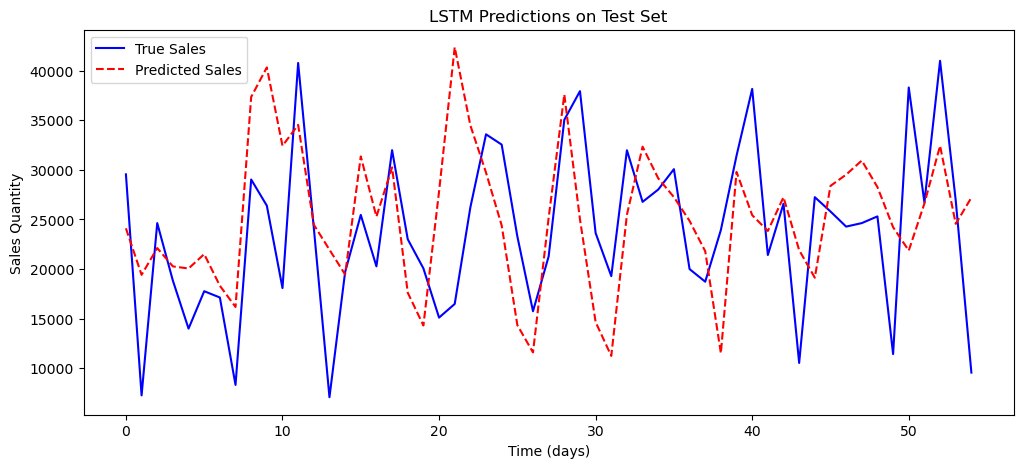

In [51]:
# 预测值与真实值可视化
plt.figure(figsize=(12,5))
plt.plot(y_true, label='True Sales', color='blue')
plt.plot(y_pred, label='Predicted Sales', color='red', linestyle='--')
plt.xlabel('Time (days)')
plt.ylabel('Sales Quantity')
plt.title('LSTM Predictions on Test Set')
plt.legend()
plt.show()